In [3]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("NLP_Final_Project"):
        subprocess.run(
            ["git", "clone", "https://github.com/tibo-chsnl/NLP_Final_Project.git"],
            check=True,
        )
    os.chdir("NLP_Final_Project")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torch", "mlflow", "dagshub", "matplotlib"],
        check=True,
    )

    subprocess.run(
        [
            "curl",
            "-L",
            "-o",
            "data/dev-v2.0.json",
            "https://rajpurkar.github.io/SQuAD-explorer/dataset/dev-v2.0.json",
        ],
        check=True,
    )
    subprocess.run(
        [
            "curl",
            "-L",
            "-o",
            "data/train-v2.0.json",
            "https://rajpurkar.github.io/SQuAD-explorer/dataset/train-v2.0.json",
        ],
        check=True,
    )
else:
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir("..")

In [4]:
import json
import os

import torch

from model.qa_model import QAModel
from src.data.loader import load_squad
from src.data.preprocessing import tokenize
from src.training.dataset import build_vocab_from_dataset, create_dataloader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

train_ds = load_squad("data/train-v2.0.json")
dev_ds = load_squad("data/dev-v2.0.json")
print(f"Train: {train_ds.stats()}")
print(f"Dev: {dev_ds.stats()}")

Device: cpu
Train: {'total': 130319, 'answerable': 86821, 'unanswerable': 43498, 'unique_contexts': 19029}
Dev: {'total': 11873, 'answerable': 5928, 'unanswerable': 5945, 'unique_contexts': 1204}


## Build Vocabulary & DataLoaders

In [ ]:
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
DROPOUT = 0.2
BATCH_SIZE = 64 if device.type == "cuda" else 32
LR = 0.001
EPOCHS = 20
PATIENCE = 3
MAX_CONTEXT_LEN = 400
MAX_QUESTION_LEN = 60
MIN_FREQ = 2
MAX_VOCAB_SIZE = 50000

vocab = build_vocab_from_dataset(train_ds, min_freq=MIN_FREQ, max_size=MAX_VOCAB_SIZE)
print(f"Vocab size: {len(vocab)}")

train_loader = create_dataloader(
    train_ds.answerable,
    vocab,
    batch_size=BATCH_SIZE,
    shuffle=True,
    max_context_len=MAX_CONTEXT_LEN,
    max_question_len=MAX_QUESTION_LEN,
)
val_loader = create_dataloader(
    dev_ds.answerable,
    vocab,
    batch_size=BATCH_SIZE,
    shuffle=False,
    max_context_len=MAX_CONTEXT_LEN,
    max_question_len=MAX_QUESTION_LEN,
)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Vocab size: 50002
Train batches: 2713, Val batches: 185


## Initialize Model

In [6]:
model = QAModel(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 6,813,962
Trainable parameters: 6,813,962


## Training Loop

In [ ]:
import time

import torch.nn as nn
from tqdm.auto import tqdm

from src.training.trainer import evaluate

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)
loss_fn = nn.CrossEntropyLoss()
os.makedirs("checkpoints", exist_ok=True)

best_f1 = 0.0
patience_counter = 0
history = []

print(f"Training {EPOCHS} epochs on {device} | batch_size={BATCH_SIZE}")
print("-" * 70)
t0 = time.time()

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    num_batches = 0
    epoch_start = time.time()

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}",
        leave=True,
    )
    for batch in pbar:
        context_ids = batch["context_ids"].to(device)
        question_ids = batch["question_ids"].to(device)
        context_mask = batch["context_mask"].to(device)
        question_mask = batch["question_mask"].to(device)
        start_idx = batch["start_idx"].to(device)
        end_idx = batch["end_idx"].to(device)

        optimizer.zero_grad()

        start_logits, end_logits = model(
            context=context_ids,
            query=question_ids,
            context_mask=context_mask,
            query_mask=question_mask,
        )

        loss = (loss_fn(start_logits, start_idx) + loss_fn(end_logits, end_idx)) / 2
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1
        pbar.set_postfix(loss=f"{running_loss / num_batches:.4f}")

    train_loss = running_loss / max(num_batches, 1)
    val_loss, val_f1, val_em = evaluate(model, val_loader, device, vocab=vocab)
    scheduler.step(val_f1)

    epoch_time = time.time() - epoch_start
    history.append(
        {
            "epoch": epoch + 1,
            "train_loss": round(train_loss, 4),
            "val_loss": round(val_loss, 4),
            "val_f1": round(val_f1, 4),
            "val_em": round(val_em, 4),
        }
    )

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
        f" — train_loss: {train_loss:.4f}"
        f" — val_loss: {val_loss:.4f}"
        f" — F1: {val_f1:.4f} — EM: {val_em:.4f}"
        f" — lr: {current_lr:.1e} — {epoch_time:.0f}s"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), "checkpoints/best_model.pt")
        with open("checkpoints/vocab.json", "w") as f:
            json.dump(vocab, f)
        with open("checkpoints/config.json", "w") as f:
            json.dump(
                {
                    "vocab_size": len(vocab),
                    "embedding_dim": EMBEDDING_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "dropout": DROPOUT,
                },
                f,
            )
        print(f"  -> Best model saved (F1: {val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(
                f"  -> Early stopping after {PATIENCE}"
                f" epochs without improvement"
                f" (best F1: {best_f1:.4f})"
            )
            break

total_time = time.time() - t0
print("-" * 70)
print(f"Done in {total_time / 60:.1f} min. Best F1: {best_f1:.4f}")

## Training Curves

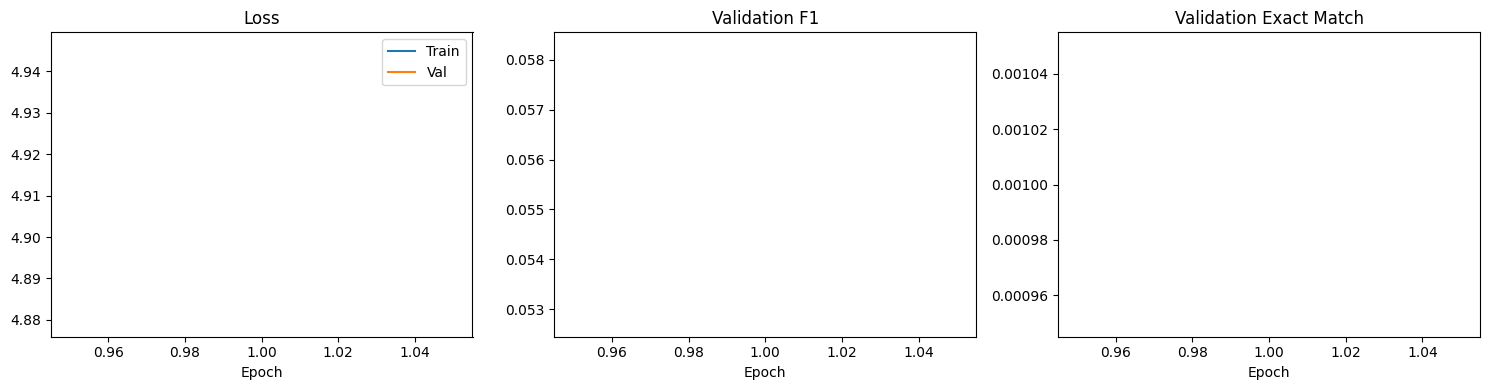

In [8]:
import matplotlib.pyplot as plt

epochs_range = [h["epoch"] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, [h["train_loss"] for h in history], label="Train")
axes[0].plot(epochs_range, [h["val_loss"] for h in history], label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, [h["val_f1"] for h in history], color="green")
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_range, [h["val_em"] for h in history], color="orange")
axes[2].set_title("Validation Exact Match")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("checkpoints/training_curves.png", dpi=150)
plt.show()

## Log to MLflow & Save

In [9]:
import mlflow
import mlflow.pytorch

try:
    from src.tracking.mlflow_setup import init_tracking

    init_tracking()
except Exception as e:
    print(f"DagsHub init skipped: {e}")
    mlflow.set_experiment("QA_Model_Training")

with mlflow.start_run(run_name="bidaf_training") as run:
    mlflow.log_params(
        {
            "embedding_dim": EMBEDDING_DIM,
            "hidden_dim": HIDDEN_DIM,
            "dropout": DROPOUT,
            "batch_size": BATCH_SIZE,
            "learning_rate": LR,
            "epochs": EPOCHS,
            "max_context_len": MAX_CONTEXT_LEN,
            "max_question_len": MAX_QUESTION_LEN,
            "vocab_size": len(vocab),
        }
    )

    best = max(history, key=lambda h: h["val_f1"])
    mlflow.log_metrics(
        {
            "best_val_f1": best["val_f1"],
            "best_val_em": best["val_em"],
            "final_train_loss": history[-1]["train_loss"],
            "final_val_loss": history[-1]["val_loss"],
        }
    )

    for h in history:
        mlflow.log_metrics(
            {
                "train_loss": h["train_loss"],
                "val_loss": h["val_loss"],
                "val_f1": h["val_f1"],
                "val_em": h["val_em"],
            },
            step=h["epoch"],
        )

    model.load_state_dict(torch.load("checkpoints/best_model.pt", weights_only=True))
    mlflow.pytorch.log_model(model, "model")

    mlflow.log_artifacts("checkpoints")

    print(f"MLflow Run ID: {run.info.run_id}")
    print(f"Best F1: {best['val_f1']}, Best EM: {best['val_em']}")

/Users/alondebasc/NLP_Final_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DagsHub init skipped: Missing Dagshub credentials. Please set DAGSHUB_USER_NAME and DAGSHUB_REPO_NAME in your .env file, or pass them directly to init_tracking().


2026/03/01 15:30:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/01 15:30:28 INFO mlflow.store.db.utils: Updating database tables
2026/03/01 15:30:29 INFO mlflow.tracking.fluent: Experiment with name 'QA_Model_Training' does not exist. Creating a new experiment.
2026/03/01 15:30:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 15:30:29 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/01 15:30:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


MLflow Run ID: 4b5195af6ec04b96b6ef5fc43ad46921
Best F1: 0.0555, Best EM: 0.001


## Quick Inference Demo

In [10]:
model.eval()

context = (
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars"
    " in Paris. It was constructed from 1887 to 1889."
)
question = "Where is the Eiffel Tower located?"

context_tokens = tokenize(context)
question_tokens = tokenize(question)

unk = vocab.get("<UNK>", 1)
c_ids = torch.tensor([[vocab.get(t, unk) for t in context_tokens]], device=device)
q_ids = torch.tensor([[vocab.get(t, unk) for t in question_tokens]], device=device)
c_mask = torch.ones_like(c_ids, dtype=torch.bool)
q_mask = torch.ones_like(q_ids, dtype=torch.bool)

with torch.no_grad():
    start_logits, end_logits = model(
        context=c_ids,
        query=q_ids,
        context_mask=c_mask,
        query_mask=q_mask,
    )

start = torch.argmax(start_logits, dim=1).item()
end = torch.argmax(end_logits, dim=1).item()
if end < start:
    end = start
answer_tokens = context_tokens[start : end + 1]
answer = " ".join(answer_tokens)

print(f"Context: {context}")
print(f"Question: {question}")
print(f"Answer: {answer}")

Context: The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris. It was constructed from 1887 to 1889.
Question: Where is the Eiffel Tower located?
Answer: the eiffel tower is a wrought - iron lattice tower on the champ de mars in paris . it was constructed from 1887 to 1889
